**If you haven't already, please hit :**

`File` -> `Save a Copy in Drive`

**to copy this notebook to your Google drive, and work on a copy. If you don't do this, your changes won't be saved!**



---



Si aún no lo ha hecho, presione:
`Archivo` -> `Guardar una copia a drive`

**para copiar este cuaderno en su unidad de Google y trabajar en una copia. ¡Si no hace esto, sus cambios no se guardarán!**

**Rules:**

Run cells from top to bottom *once*.

Don't edit the logic code (prevents bugs during the demo!).

In [8]:
# @title Section 1: Setup & Helper Functions
import numpy as np
import matplotlib.pyplot as plt
import random

# Reproducibility
np.random.seed(42)
random.seed(42)

def plot_grid(env, agent_pos=None, title="Gridworld"):
    """
    Visualizes the grid using matrix coordinates (0,0 is top-left).
    """
    fig, ax = plt.subplots(figsize=(6, 6))

    # Create a background grid (0 = empty, 1 = wall)
    grid_map = np.zeros((env.height, env.width))
    for (r, c) in env.walls:
        grid_map[r, c] = 1

    # Plot the grid (White = Empty, Gray = Wall)
    ax.imshow(grid_map, cmap='binary', vmin=0, vmax=1)

    # Draw grid lines manually
    ax.set_xticks(np.arange(-0.5, env.width, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, env.height, 1), minor=True)
    ax.grid(which='minor', color='black', linestyle='-', linewidth=1)
    ax.tick_params(which='minor', size=0)
    ax.set_xticks([]) # Hide major ticks
    ax.set_yticks([])

    # Annotate Start and Goal
    # Note: Text uses (x, y) = (col, row)
    ax.text(env.start[1], env.start[0], 'S', ha='center', va='center', fontsize=20, color='blue', fontweight='bold')
    ax.text(env.goal[1], env.goal[0], 'G', ha='center', va='center', fontsize=20, color='green', fontweight='bold')

    # Draw Agent
    if agent_pos:
        circle = plt.Circle((agent_pos[1], agent_pos[0]), 0.3, color='blue', alpha=0.8)
        ax.add_patch(circle)

    ax.set_title(title)
    plt.show()

def plot_policy(Q, env, title="Learned Strategy"):
    """
    Overlays the best action arrows on the grid.
    Includes a heatmap of the 'Value' (max Q) to show where the agent wants to go.
    """
    fig, ax = plt.subplots(figsize=(6, 6))

    # 1. Calculate Value Map (Max Q per state) for background heatmap
    value_map = np.max(Q, axis=2)
    # Mask walls so they don't mess up the color scale
    for (r, c) in env.walls:
        value_map[r, c] = np.nan

    # Plot Heatmap
    im = ax.imshow(value_map, cmap='Greens', alpha=0.6)
    plt.colorbar(im, ax=ax, label="Value (How good is this spot?)", fraction=0.046, pad=0.04)

    # 2. Draw Walls
    for (r, c) in env.walls:
        rect = plt.Rectangle((c - 0.5, r - 0.5), 1, 1, facecolor='gray')
        ax.add_patch(rect)

    # 3. Draw Grid Lines
    ax.set_xticks(np.arange(-0.5, env.width, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, env.height, 1), minor=True)
    ax.grid(which='minor', color='black', linestyle='-', linewidth=0.5)
    ax.set_xticks([])
    ax.set_yticks([])

    # 4. Draw Arrows for Policy
    # Action map: 0:Up, 1:Right, 2:Down, 3:Left
    # In Matrix Plots (imshow): Up is y-1, Down is y+1
    arrow_dirs = {
        0: (0, -0.4),  # Up (Negative Y in matrix)
        1: (0.4, 0),   # Right
        2: (0, 0.4),   # Down (Positive Y in matrix)
        3: (-0.4, 0)   # Left
    }

    for r in range(env.height):
        for c in range(env.width):
            if (r, c) == env.goal: continue
            if (r, c) in env.walls: continue

            # Find best action
            best_action = np.argmax(Q[r, c])
            dx, dy = arrow_dirs[best_action]

            ax.arrow(c, r, dx, dy, head_width=0.1, head_length=0.1, fc='black', ec='black')

    ax.text(env.start[1], env.start[0], 'S', ha='center', va='center', fontsize=15, fontweight='bold', color='blue')
    ax.text(env.goal[1], env.goal[0], 'G', ha='center', va='center', fontsize=15, fontweight='bold', color='white')
    ax.set_title(title)
    plt.show()

def plot_learning_curve(rewards):
    plt.figure(figsize=(8, 4))
    window = 50
    if len(rewards) >= window:
        smoothed = np.convolve(rewards, np.ones(window)/window, mode='valid')
        plt.plot(smoothed)
    else:
        plt.plot(rewards)
    plt.xlabel("Episodes")
    plt.ylabel("Return (Total Reward)")
    plt.title("Learning Curve")
    plt.grid(True, alpha=0.3)
    plt.show()

print("Setup Complete. Ready to start!")

Setup Complete. Ready to start!


# Section 2: The Environment (Gridworld)
We are in a 5x5 grid.

**S**: Start

**G**: Goal (+1.0 reward)

**Gray Blocks**: Walls

**Step Cost**: -0.01 (To encourage speed)

**Actions**: 0: Up, 1: Right, 2: Down, 3: Left

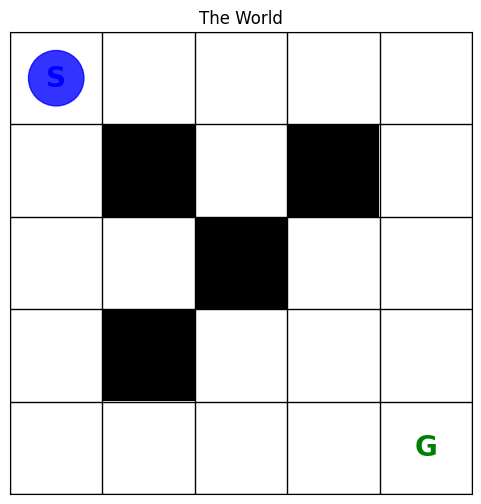

In [9]:
class GridWorld:
    def __init__(self, step_cost=-0.01):
        self.height = 5
        self.width = 5
        self.start = (0, 0)
        self.goal = (4, 4)
        # Walls at (1,1), (2,2), (1,3), (3,1)
        self.walls = [(1, 1), (2, 2), (1, 3), (3, 1)]
        self.step_cost = step_cost
        self.agent_pos = self.start

    def reset(self):
        self.agent_pos = self.start
        return self.agent_pos

    def step(self, action):
        # Actions: 0:Up, 1:Right, 2:Down, 3:Left
        # Matrix indexing: Up decreases row, Down increases row
        moves = {
            0: (-1, 0), # Up
            1: (0, 1),  # Right
            2: (1, 0),  # Down
            3: (0, -1)  # Left
        }
        dr, dc = moves[action]

        current_r, current_c = self.agent_pos
        new_r = current_r + dr
        new_c = current_c + dc

        # Check Bounds
        if new_r < 0 or new_r >= self.height or new_c < 0 or new_c >= self.width:
            new_pos = self.agent_pos
        # Check Walls
        elif (new_r, new_c) in self.walls:
            new_pos = self.agent_pos
        else:
            new_pos = (new_r, new_c)

        self.agent_pos = new_pos

        if new_pos == self.goal:
            return new_pos, 1.0, True
        else:
            return new_pos, self.step_cost, False

# Test the visual
env = GridWorld()
plot_grid(env, agent_pos=(0,0), title="The World")

Average Reward (Random): -0.20000000000000004


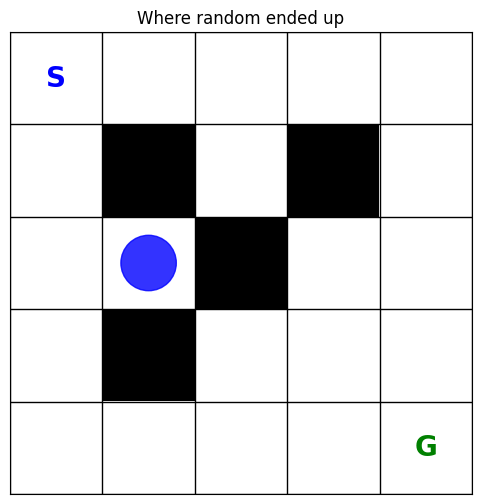

In [10]:
# Section 3: Baseline - Random Walking
# Let's see how a "dumb" agent performs

env = GridWorld()
total_rewards = []

for episode in range(5): # Run 5 times
    state = env.reset()
    done = False
    ep_reward = 0
    steps = 0

    while not done and steps < 20: # Cap at 20 steps for visuals
        action = np.random.choice(4) # Pick random action
        next_state, reward, done = env.step(action)
        ep_reward += reward
        state = next_state
        steps += 1

    total_rewards.append(ep_reward)

print(f"Average Reward (Random): {np.mean(total_rewards)}")
plot_grid(env=env, agent_pos=state, title="Where random ended up")

# Section 4: Q-Learning Training
We will use **Q-learning**. The agent maintains a "cheat sheet" (Q-table) estimating how good it is to take an action in a state.

Training default agent...


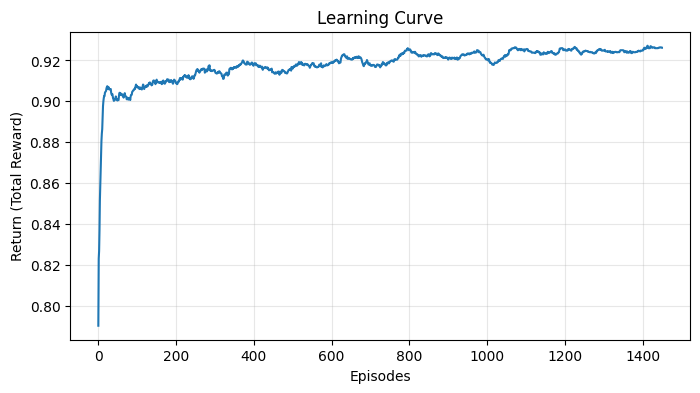

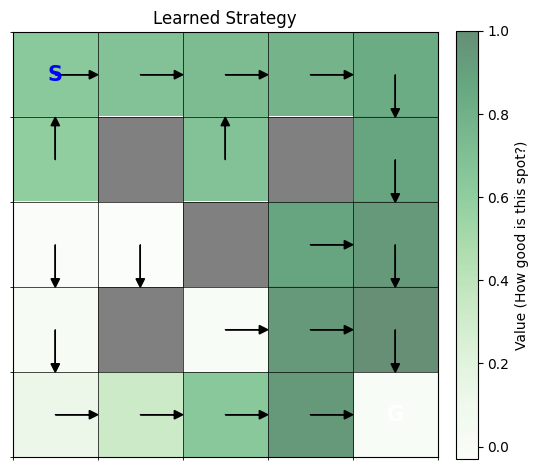

In [11]:
def train_agent(episodes=1500, alpha=0.2, gamma=0.95, eps_start=0.2, step_cost=-0.01):
    env = GridWorld(step_cost=step_cost)
    Q = np.zeros((5, 5, 4))
    rewards_history = []
    epsilon = eps_start

    for ep in range(episodes):
        state = env.reset()
        done = False
        total_r = 0

        while not done:
            r, c = state
            if np.random.rand() < epsilon:
                action = np.random.randint(4)
            else:
                action = np.argmax(Q[r, c])

            next_state, reward, done = env.step(action)
            nr, nc = next_state
            best_next = np.max(Q[nr, nc])
            Q[r, c, action] += alpha * (reward + gamma * best_next - Q[r, c, action])

            state = next_state
            total_r += reward

        rewards_history.append(total_r)
        if epsilon > 0.05: epsilon *= 0.999

    return Q, rewards_history, env

# Run Default
print("Training default agent...")
Q_default, rewards, final_env = train_agent()
plot_learning_curve(rewards)
# Note: We pass the 'final_env' to ensure walls match the training instance
plot_policy(Q_default, final_env, title="Learned Strategy")

# Section 5: Experiments
Edit the variables in the code block below, run it, and analyze the change.

**A. Exploration (Epsilon)**

Change EPS_START to 0.0. Run.

Change EPS_START to 0.5. Run.

Question: Why does the agent fail if it never explores?

**B. Vision (Gamma)**

Change GAMMA to 0.1. Run.

Change GAMMA to 0.99. Run.

Question: Does the low-gamma agent care about the Goal, or just avoiding the step cost?

**C. Incentives (Reward Shaping)**

Change STEP_COST to 0.0. Run.

Change STEP_COST to -0.1. Run.

Question: Does the agent take the shortest path if walking is "free" (0.0)?

Running Experiment with Eps=0.2, Gamma=0.95, Cost=-0.01


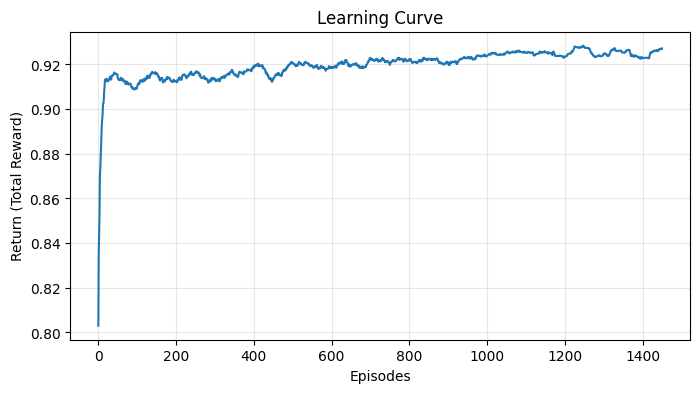

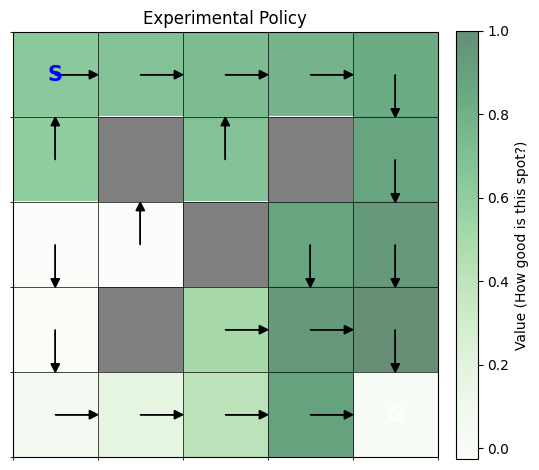

In [12]:
# --- EDIT THESE KNOBS ---
EPS_START = 0.2     # Default 0.2. Try 0.0 vs 0.5
GAMMA = 0.95      # Default 0.95. Try 0.1 vs 0.99
STEP_COST = -0.01 # Default -0.01. Try 0.0 vs -0.1
# ------------------------

print(f"Running Experiment with Eps={EPS_START}, Gamma={GAMMA}, Cost={STEP_COST}")
Q_exp, rewards_exp, exp_env = train_agent(
    episodes=1500,
    alpha=0.2,
    gamma=GAMMA,
    eps_start=EPS_START,
    step_cost=STEP_COST
)

plot_learning_curve(rewards_exp)
plot_policy(Q_exp, exp_env, title="Experimental Policy")

# Section 6: Discussion
**Discuss with a partner:**

When you ran your experiments, what happened to the arrows (policy) or the curve?

What does this tell you about designing RL systems for the real world?